In [50]:
import pandas as pd                        
import numpy as np                         
import matplotlib.pyplot as plt             
import seaborn as sns

In [51]:
df=pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [52]:
print("Column names:")
print(df.columns.tolist())
print()

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']



In [53]:
print("\nDataFrame Info:")
df.info()
print()


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal      

In [54]:
print("\nSummary Statistics for Categorical Columns:")
display(df.describe(include='object'))


Summary Statistics for Categorical Columns:


C:\Users\iffat\AppData\Local\Temp\ipykernel_9556\2949887195.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [55]:
print("Missing values per column:")
print(df.isnull().sum())
print()

Missing values per column:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                         

<Axes: >

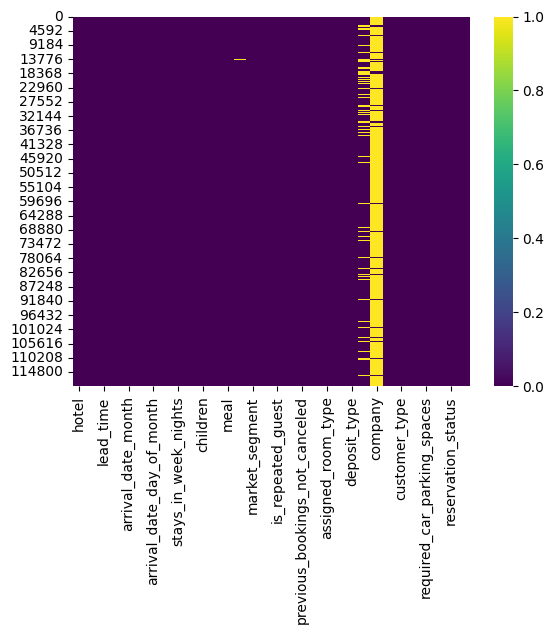

In [56]:
sns.heatmap(df.isnull(),cmap = 'viridis')

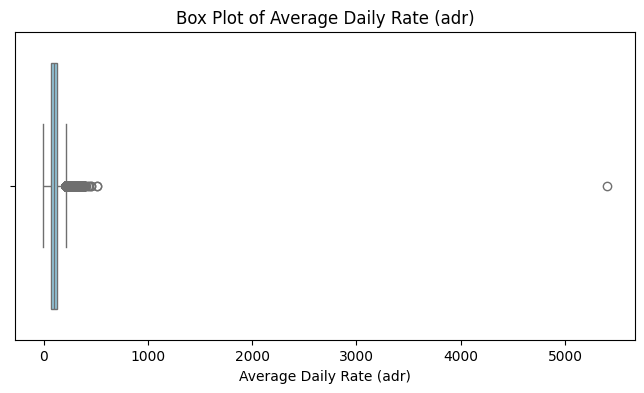

In [57]:
# Outlier detection for 'adr' (Average Daily Rate)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adr'], color='skyblue')
plt.title('Box Plot of Average Daily Rate (adr)')
plt.xlabel('Average Daily Rate (adr)')
plt.show()

In [58]:
outlier_threshold = 5000
df = df[df['adr'] < outlier_threshold]
print(f"Data shape after removing adr outliers (adr < {outlier_threshold}): {df.shape}")


Data shape after removing adr outliers (adr < 5000): (119389, 32)


In [59]:
cols_to_drop = ['agent', 'company']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['agent', 'company']


In [60]:
df.dropna(inplace=True)
print(f"Data shape after dropping NA: {df.shape}")

Data shape after dropping NA: (118897, 30)


In [61]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
duplicate_rows

Number of duplicate rows: 31984


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,A,1,No Deposit,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,E,0,No Deposit,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,D,0,No Deposit,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,A,0,No Deposit,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,D,0,No Deposit,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [62]:
df.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {df.shape}")

Data shape after removing duplicates: (86913, 30)


In [63]:
print("\nSummary statistics for numerical columns:")
display(df.describe())


Summary statistics for numerical columns:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000
mean,0.275931,80.203261,2016.211844,26.841853,15.818347,1.007559,2.628974,1.878603,0.139254,0.010815,0.039246,0.030237,0.176763,0.271904,0.753731,106.519911,0.083474,0.699550
std,0.446985,86.103261,0.685992,13.654110,8.834535,1.028821,2.043864,0.625884,0.456850,0.113511,0.194181,0.369631,1.718149,0.728177,10.043367,51.944108,0.280441,0.831881
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,12.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000
50%,0.000000,50.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.410000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000


In [64]:
# Calculate the average lead time for each hotel type
avg_lead_time_by_hotel = df.groupby('hotel')['lead_time'].mean()

# Display the result
print("Average Lead Time by Hotel Type:")
print(avg_lead_time_by_hotel)

Average Lead Time by Hotel Type:
hotel
City Hotel      77.691122
Resort Hotel    84.206714
Name: lead_time, dtype: float64


In [65]:
def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['arrival_date_month'].apply(get_season)

In [66]:
season_total = df['season'].value_counts()
print(season_total)

season
Summer    29001
Spring    23666
Fall      18490
Winter    15756
Name: count, dtype: int64


In [67]:
season_hotel = df.groupby(['season', 'hotel']).size().unstack()
print("Total reservations by season and hotel type:")
print(season_hotel)

Total reservations by season and hotel type:
hotel   City Hotel  Resort Hotel
season                          
Fall         11384          7106
Spring       15341          8325
Summer       17331         11670
Winter        9347          6409


In [68]:

df['is_family'] = df.apply(
    lambda row: 'group' if row['adults'] > 2 else (
        'full_family' if row['adults'] > 2 and (row['children'] > 0 or row['babies'] > 0) else (
            'family' if row['adults'] in [1, 2] and (row['children'] > 0 or row['babies'] > 0) else (
                'double' if row['adults'] == 2 else 'single'
            )
        )
    ), axis=1
)


In [69]:
family_counts = df['is_family'].value_counts()
print("Total number of each family type:")
print(family_counts)

print("Total cancellation rate of each family type:")
df.groupby('is_family')['is_canceled'].mean()

Total number of each family type:
is_family
double    56424
single    16149
family     8334
group      6006
Name: count, dtype: int64
Total cancellation rate of each family type:


is_family
double    0.282451
family    0.337893
group     0.342491
single    0.196421
Name: is_canceled, dtype: float64

In [70]:
full_family_exists = (df['is_family'] == 'full_family').any()
print(f"Is there any full family? {full_family_exists}")

Is there any full family? False


In [71]:
df.groupby(['hotel'])['is_canceled'].mean()

hotel
City Hotel      0.300320
Resort Hotel    0.237064
Name: is_canceled, dtype: float64

In [116]:
lead_norm = (df['lead_time'] - df['lead_time'].min()) / (df['lead_time'].max() - df['lead_time'].min())
prev_cancel_norm = np.where(df['previous_cancellations'] > 0, 1, 0)
special_req_norm = np.where(df['total_of_special_requests'] == 0, 1, 0)
df['cancellation_risk_score'] = (0.5 * lead_norm + 0.3 * prev_cancel_norm + 0.2 * special_req_norm)
print("\nCancellation risk score — canceled vs not canceled:")
print(df.groupby('is_canceled')['cancellation_risk_score'].mean().round(4))
print("Risk score percentiles (overall):")
print(np.percentile(df['cancellation_risk_score'], [25, 50, 75, 90]))


Cancellation risk score — canceled vs not canceled:
is_canceled
0    0.1426
1    0.2072
Name: cancellation_risk_score, dtype: float64
Risk score percentiles (overall):
[0.03731343 0.2        0.23663501 0.30786974]


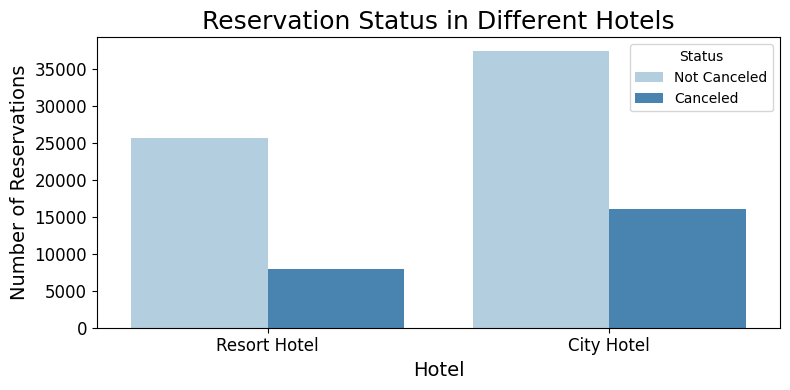

In [97]:
plt.figure(figsize=(8, 4))
ax1 = sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df,
    palette='Blues'
)

# Set legend outside the plot for clarity
ax1.legend_.set_bbox_to_anchor((1, 1))
plt.title('Reservation Status in Different Hotels', fontsize=18)
plt.xlabel('Hotel', fontsize=14)
plt.ylabel('Number of Reservations', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(['Not Canceled', 'Canceled'], title='Status', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [98]:
def lead_time_category(x):
    if x < 7:
        return 'Last_Minute'
    elif x < 30:
        return 'Short_Term'
    elif x < 90:
        return 'Mid_Term'
    else:
        return 'Long_Term'

df['lead_time_category'] = df['lead_time'].apply(lead_time_category)

In [99]:
canceled_data = df[df['is_canceled'] == 1].groupby('lead_time_category').size()
print("Total canceled data based on lead_time_category:")
print(canceled_data)

Total canceled data based on lead_time_category:
lead_time_category
Last_Minute     1372
Long_Term      11119
Mid_Term        7370
Short_Term      4121
dtype: int64


In [100]:
# Group by lead_time_category and is_family, then sum the is_canceled column
cancellation_summary = df.groupby(['lead_time_category', 'is_family'])['is_canceled'].sum()

# Display the result
print("Total cancellations for each family type within each lead time category:")
print(cancellation_summary)


Total cancellations for each family type within each lead time category:
lead_time_category  is_family
Last_Minute         double        734
                    family         90
                    group          57
                    single        491
Long_Term           double       7709
                    family       1388
                    group        1029
                    single        993
Mid_Term            double       4876
                    family        903
                    group         697
                    single        894
Short_Term          double       2618
                    family        435
                    group         274
                    single        794
Name: is_canceled, dtype: int64


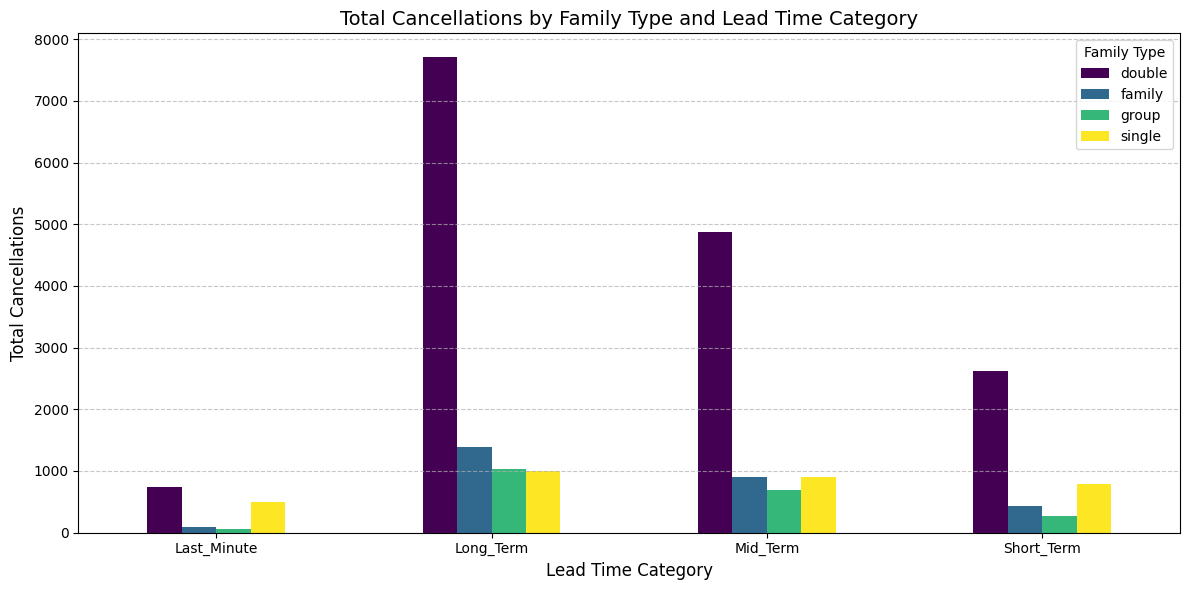

In [101]:
# Unstack the cancellation_summary for better visualization
cancellation_summary_unstacked = cancellation_summary.unstack()

# Plot the grouped bar chart
cancellation_summary_unstacked.plot(kind='bar', figsize=(12, 6), colormap='viridis')

# Add labels and title
plt.title('Total Cancellations by Family Type and Lead Time Category', fontsize=14)
plt.xlabel('Lead Time Category', fontsize=12)
plt.ylabel('Total Cancellations', fontsize=12)
plt.legend(title='Family Type', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [102]:
cancel_by_lead = df.groupby('lead_time_category')['is_canceled'].mean()
print(cancel_by_lead)

lead_time_category
Last_Minute    0.081618
Long_Term      0.367789
Mid_Term       0.320867
Short_Term     0.243817
Name: is_canceled, dtype: float64


In [103]:
correlation = df[['lead_time', 'is_canceled']].corr()
print(correlation)

             lead_time  is_canceled
lead_time     1.000000     0.183696
is_canceled   0.183696     1.000000


In [104]:
print(df['lead_time'].describe())

outliers = df[df['lead_time'] > 300]
print(f"Outliers count: {len(outliers)}")

count    86913.000000
mean        80.203261
std         86.103261
min          0.000000
25%         12.000000
50%         50.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64
Outliers count: 2286


In [105]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
PRT    27435
GBR    10431
FRA     8837
ESP     7250
DEU     5385
ITA     3065
IRL     3016
BEL     2081
BRA     1993
NLD     1911
Name: count, dtype: int64


In [106]:
import numpy as np

cancel_rate = np.sum(df['is_canceled']) / len(df)
print(f"Overall cancellation rate: {cancel_rate}")

Overall cancellation rate: 0.2759311035173104


In [107]:
df.groupby('hotel')['is_canceled'].mean()


hotel
City Hotel      0.300320
Resort Hotel    0.237064
Name: is_canceled, dtype: float64

In [108]:

df.groupby('deposit_type')['is_canceled'].mean()


deposit_type
No Deposit    0.267868
Non Refund    0.946911
Refundable    0.242991
Name: is_canceled, dtype: float64

In [109]:

df.groupby('market_segment')['is_canceled'].mean()


market_segment
Aviation         0.198238
Complementary    0.123209
Corporate        0.123478
Direct           0.147960
Groups           0.270462
Offline TA/TO    0.148252
Online TA        0.353999
Name: is_canceled, dtype: float64

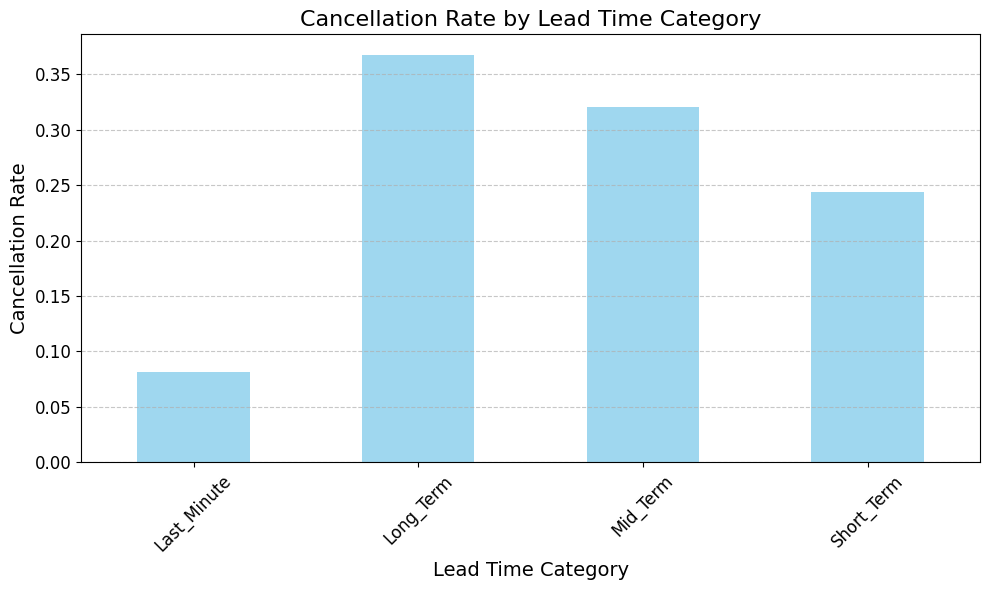

In [110]:
# Plot the cancellation rate by lead time category
plt.figure(figsize=(10, 6))
cancel_by_lead.plot(kind='bar', color='skyblue', alpha=0.8)
plt.title('Cancellation Rate by Lead Time Category', fontsize=16)
plt.xlabel('Lead Time Category', fontsize=14)
plt.ylabel('Cancellation Rate', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()





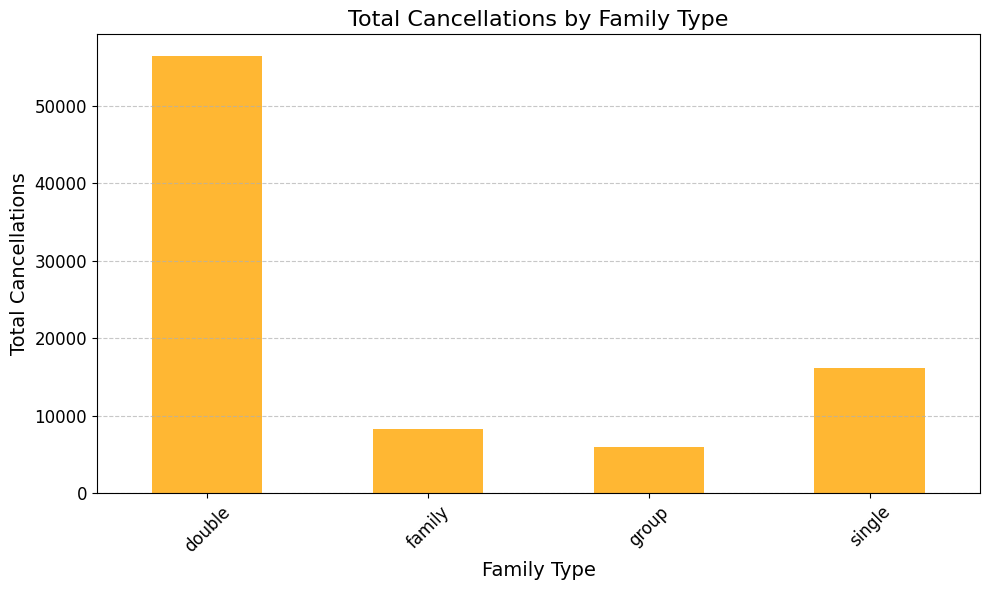

In [111]:
# Plot the total cancellations by family type
plt.figure(figsize=(10, 6))
canceled_by_family=df.groupby('is_family')['is_canceled'].count()
canceled_by_family.plot(kind='bar', color='orange', alpha=0.8)
plt.title('Total Cancellations by Family Type', fontsize=16)
plt.xlabel('Family Type', fontsize=14)
plt.ylabel('Total Cancellations', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

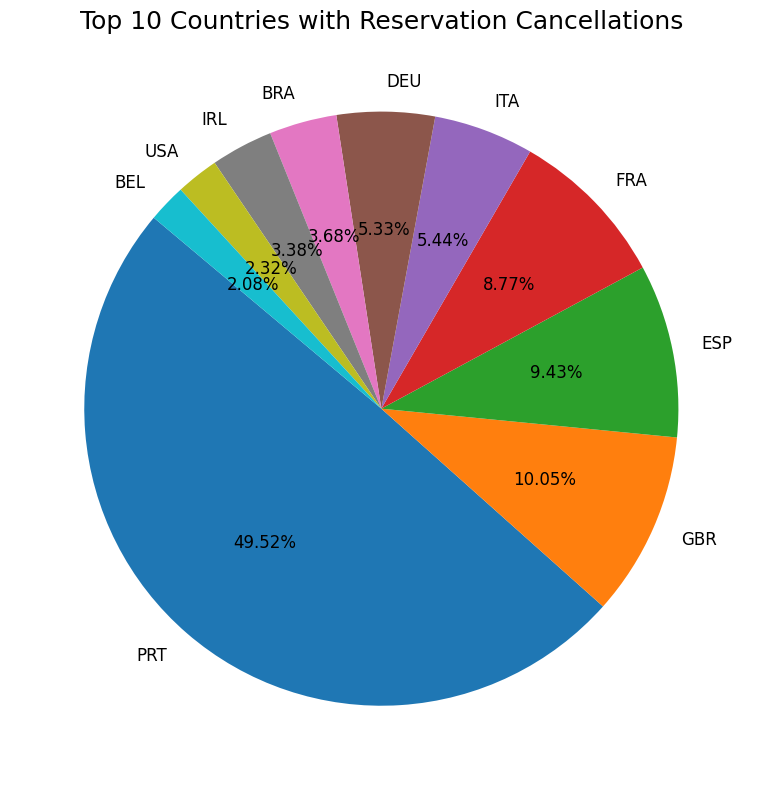

In [112]:
# Filter for canceled reservations
cancelled_data = df[df['is_canceled'] == 1]

# Get top 10 countries by number of cancellations
top_10_country = cancelled_data['country'].value_counts().head(10)

plt.figure(figsize=(8, 8))
plt.title('Top 10 Countries with Reservation Cancellations', fontsize=18)

# Pie chart
plt.pie(
    top_10_country,
    autopct='%.2f%%',
    labels=top_10_country.index,
    startangle=140,
    textprops={'fontsize': 12}
)

plt.tight_layout()
plt.show()

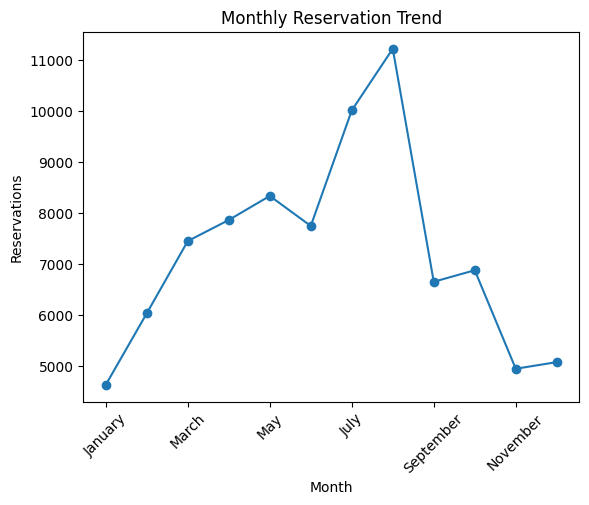

In [113]:
month_counts = df['arrival_date_month'].value_counts()

month_counts = month_counts.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

month_counts.plot(kind='line', marker='o')

plt.title("Monthly Reservation Trend")
plt.xlabel("Month")
plt.ylabel("Reservations")
plt.xticks(rotation=45)
plt.show()

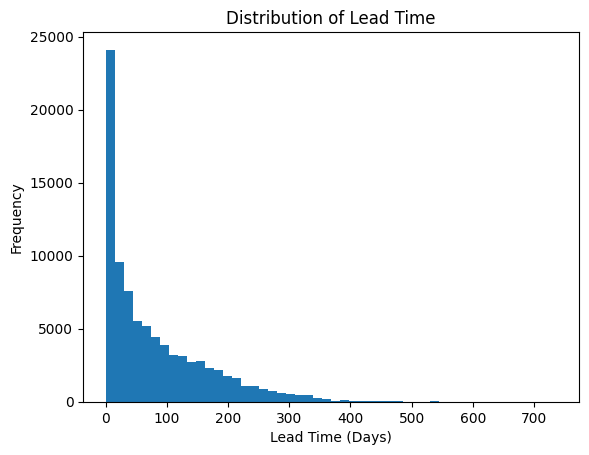

In [114]:
plt.hist(df['lead_time'], bins=50)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

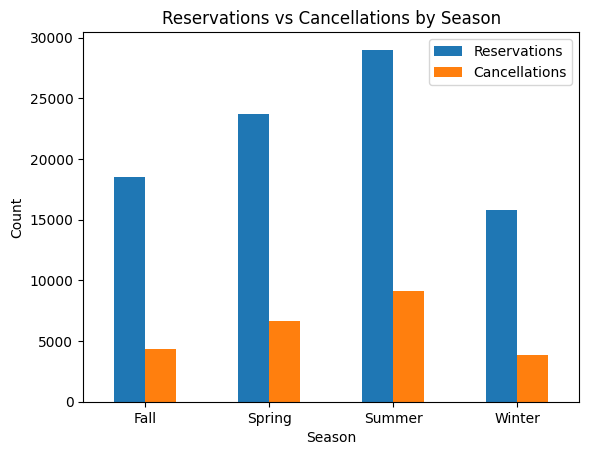

In [115]:

# Total reservations per season
reservations = df.groupby('season').size()

# Total cancellations per season
cancellations = df[df['is_canceled'] == 1].groupby('season').size()

# Combine into one DataFrame
season_data = pd.DataFrame({
    'Reservations': reservations,
    'Cancellations': cancellations
}).fillna(0)

season_data.plot(kind='bar')

plt.title("Reservations vs Cancellations by Season")
plt.xlabel("Season")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend()
plt.show()